# UNSW-NB15 — Task 3: Explainability
Group 5 · CSE475 · Track 1 (GNN)

SHAP + LIME on the XGBoost baseline (tabular, standard use case). GNNExplainer on the
GAT model instead of raw SHAP/LIME — SHAP/LIME assume flat feature vectors and don't
natively handle message-passing graph input; GNNExplainer (Ying et al., NeurIPS 2019,
cited in the course's own reference list) is the track-appropriate substitute for a
graph model. One correct and one wrong prediction, both models.

In [1]:
!pip install shap lime

In [2]:
try:
    import torch_geometric
    print("torch_geometric already installed:", torch_geometric.__version__)
except ImportError:
    import torch, os
    TORCH_VER = torch.__version__.split('+')[0]
    CUDA_VER = 'cu' + torch.version.cuda.replace('.', '') if torch.cuda.is_available() else 'cpu'
    os.system(f"pip install -q torch_geometric")
    os.system(f"pip install -q pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{TORCH_VER}+{CUDA_VER}.html")
    import torch_geometric
    print("Installed torch_geometric:", torch_geometric.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 106.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 115.3 MB/s eta 0:00:00
Installed torch_geometric: 2.8.0.post1


In [3]:
import os, pickle
import numpy as np
import pandas as pd
import shap
import lime.lime_tabular
import torch
import matplotlib.pyplot as plt
from torch_geometric.explain import Explainer, GNNExplainer

CFG = {
    'prep_dir': '/kaggle/input/datasets/shahiismyname/unsw-nb15-preprocessed-dataset',
    'graph_dir': '/kaggle/input/datasets/shahiismyname/unsw-nb15-gnn-dataset',
    'baseline_dir': '/kaggle/input/datasets/shahiismyname/baseline-output',
    'gnn_dir': '/kaggle/input/datasets/shahiismyname/gnn-output',
    'out_dir': '/kaggle/working/task3_xai_outputs',
}
os.makedirs(CFG['out_dir'], exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_pkl(folder, name):
    with open(os.path.join(folder, f'{name}.pkl'), 'rb') as f:
        return pickle.load(f)

train_processed = load_pkl(CFG['prep_dir'], 'train_processed')
test_processed = load_pkl(CFG['prep_dir'], 'test_processed')
le = load_pkl(CFG['baseline_dir'], 'label_encoder')
with open(os.path.join(CFG['baseline_dir'], 'XGBoost_model.pkl'), 'rb') as f:
    xgb_model = pickle.load(f)
preds = load_pkl(CFG['baseline_dir'], 'XGBoost_test_predictions')

drop_cols = ['flow_id', 'attack_cat', 'Label']
X_train = train_processed.drop(columns=[c for c in drop_cols if c in train_processed.columns])
X_test = test_processed.drop(columns=[c for c in drop_cols if c in test_processed.columns])
y_test = le.transform(test_processed['attack_cat'])

In [4]:
y_pred = preds['y_pred']
correct_idx = np.where(y_pred == y_test)[0][0]
wrong_idx = np.where(y_pred != y_test)[0][0]

print(f"Correct sample: idx={correct_idx}, true={le.classes_[y_test[correct_idx]]}, "
      f"pred={le.classes_[y_pred[correct_idx]]}")
print(f"Wrong sample:   idx={wrong_idx}, true={le.classes_[y_test[wrong_idx]]}, "
      f"pred={le.classes_[y_pred[wrong_idx]]}")

Correct sample: idx=0, true=Normal, pred=Normal
Wrong sample:   idx=86, true=Reconnaissance, pred=Exploits


In [5]:
# ct_ftp_cmd (and possibly others) can hold literal ' ' instead of a number in the raw data —
# same fix needed in every notebook that loads train_processed/test_processed fresh
for col in X_train.columns:
    if X_train[col].dtype == object:
        X_train[col] = pd.to_numeric(X_train[col].astype(str).str.strip(), errors='coerce').fillna(0)
        X_test[col] = pd.to_numeric(X_test[col].astype(str).str.strip(), errors='coerce').fillna(0)
        print(f"Coerced {col} to numeric")

Coerced ct_ftp_cmd to numeric


# SHAP on XGBoost

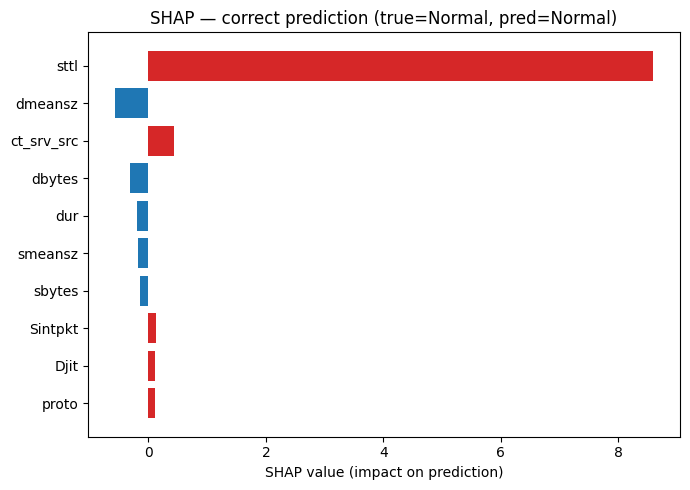

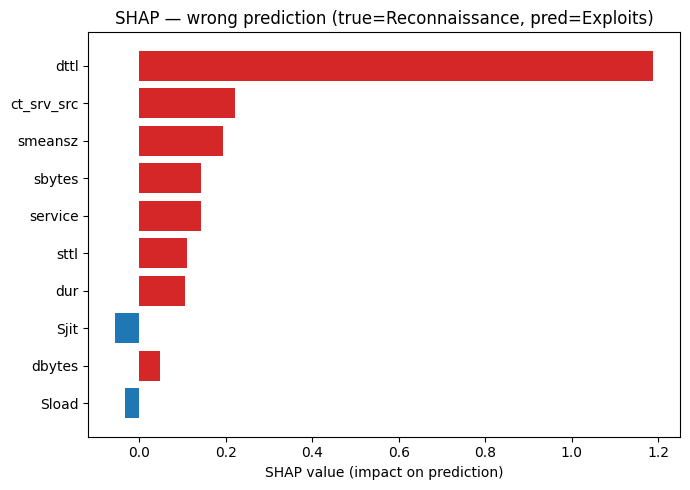

In [6]:
explainer = shap.TreeExplainer(xgb_model)
X_sample = X_test.iloc[[correct_idx, wrong_idx]]
raw_shap = explainer.shap_values(X_sample)

def get_sample_shap(raw_shap, sample_i, class_idx):
    if isinstance(raw_shap, list):
        return raw_shap[class_idx][sample_i]          # older SHAP: list per class
    arr = np.array(raw_shap)
    if arr.ndim == 3:
        return arr[sample_i, :, class_idx]             # newer SHAP: (samples, features, classes)
    return arr[sample_i]                                # binary case

for i, (idx, label) in enumerate([(correct_idx, 'correct'), (wrong_idx, 'wrong')]):
    pred_class = y_pred[idx]
    sample_shap = get_sample_shap(raw_shap, i, pred_class)
    feat_names = X_sample.columns

    order = np.argsort(np.abs(sample_shap))[::-1][:10]
    values = sample_shap[order][::-1]
    names = [feat_names[j] for j in order][::-1]
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in values]

    plt.figure(figsize=(7, 5))
    plt.barh(range(len(values)), values, color=colors)
    plt.yticks(range(len(values)), names)
    plt.xlabel("SHAP value (impact on prediction)")
    plt.title(f"SHAP — {label} prediction (true={le.classes_[y_test[idx]]}, pred={le.classes_[y_pred[idx]]})")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['out_dir'], f'shap_{label}.png'), dpi=150)
    plt.show()

# LIME on XGBoost

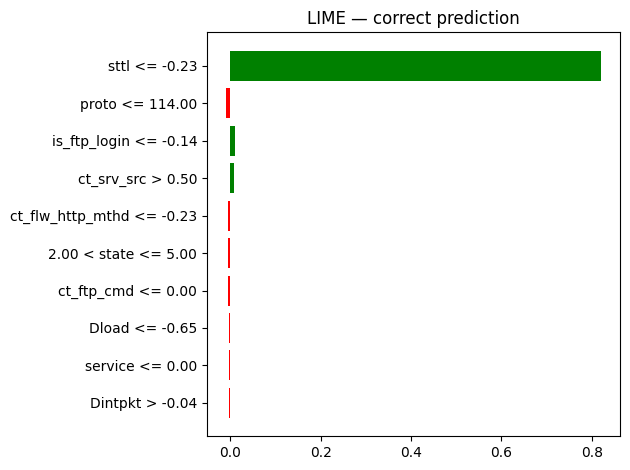

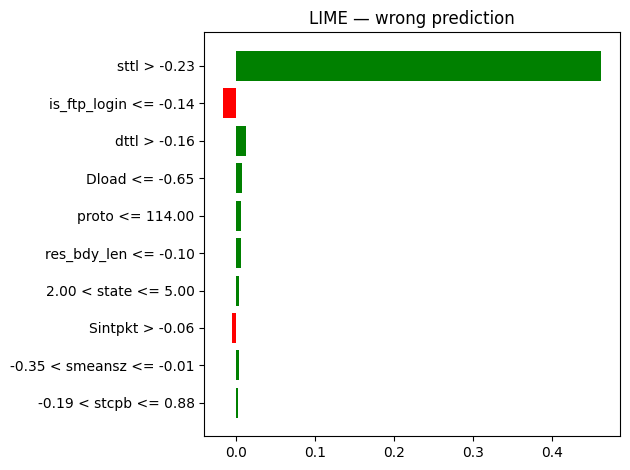

In [7]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=X_train.columns.tolist(),
    class_names=le.classes_, mode='classification')

for idx, label in [(correct_idx, 'correct'), (wrong_idx, 'wrong')]:
    exp = lime_explainer.explain_instance(X_test.iloc[idx].values, xgb_model.predict_proba,
                                           num_features=10, top_labels=1)
    fig = exp.as_pyplot_figure(label=exp.available_labels()[0])
    plt.title(f"LIME — {label} prediction")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['out_dir'], f'lime_{label}.png'), dpi=150)
    plt.show()

# Rebuild the GAT graph and architecture

In [8]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from sklearn.preprocessing import StandardScaler

# --- load what this cell needs (not loaded earlier in this notebook) ---
side_train = load_pkl(CFG['prep_dir'], 'side_train')
side_test = load_pkl(CFG['prep_dir'], 'side_test')
nodes_train = load_pkl(CFG['graph_dir'], 'nodes_train')
nodes_test = load_pkl(CFG['graph_dir'], 'nodes_test')
edges_temporal_train = load_pkl(CFG['graph_dir'], 'edges_temporal_train')
edges_temporal_test = load_pkl(CFG['graph_dir'], 'edges_temporal_test')

CFG['node_feature_cols'] = ['avg_duration', 'total_bytes', 'num_connections',
                             'num_as_src', 'num_as_dst', 'num_unique_partners']
CFG['edge_feature_cols'] = ['transition_count', 'time_gap', 'proto_changed',
                             'port_changed', 'byte_diff', 'pkt_diff']
CFG['heads'], CFG['hidden_dim'], CFG['dropout'], CFG['val_frac'] = 2, 8, 0.3, 0.2


class GAT(nn.Module):
    def __init__(self, in_dim, edge_dim, hidden_dim, out_dim, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, dropout=dropout, edge_dim=edge_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, concat=False,
                               dropout=dropout, edge_dim=edge_dim)

    def forward(self, x, edge_index, edge_attr):
        x = F.elu(self.gat1(x, edge_index, edge_attr))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index, edge_attr)
        return x


def derive_host_labels(side_df, processed_df, flow_id_col, flow_host_cols, label_col):
    flow_labels = side_df[[flow_id_col] + flow_host_cols].merge(
        processed_df[[flow_id_col, label_col]], on=flow_id_col, how='inner')
    long = pd.concat([
        flow_labels[[flow_host_cols[0], label_col]].rename(columns={flow_host_cols[0]: 'host'}),
        flow_labels[[flow_host_cols[1], label_col]].rename(columns={flow_host_cols[1]: 'host'}),
    ], ignore_index=True)
    return long.groupby('host')[label_col].max().rename('host_label').reset_index()


def build_graph(nodes_df, edges_df, host_labels_df, node_feature_cols, edge_feature_cols):
    nodes_df = nodes_df.merge(host_labels_df, on='host', how='left')
    nodes_df['host_label'] = nodes_df['host_label'].fillna(0).astype(int)
    nodes_df = nodes_df.sort_values('node_index').reset_index(drop=True)

    x = torch.tensor(nodes_df[node_feature_cols].fillna(0).values, dtype=torch.float)
    y = torch.tensor(nodes_df['host_label'].values, dtype=torch.long)
    edge_index = torch.tensor(np.vstack([edges_df['source_host_idx'].values, edges_df['target_host_idx'].values]),
                               dtype=torch.long)
    edge_attr = torch.tensor(edges_df[edge_feature_cols].fillna(0).values, dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


flow_id_col, flow_host_cols, flow_label_col = 'flow_id', ['srcip', 'dstip'], 'Label'
host_labels_train = derive_host_labels(side_train, train_processed, flow_id_col, flow_host_cols, flow_label_col)
host_labels_test = derive_host_labels(side_test, test_processed, flow_id_col, flow_host_cols, flow_label_col)

node_scaler = StandardScaler()
nodes_train[CFG['node_feature_cols']] = node_scaler.fit_transform(nodes_train[CFG['node_feature_cols']])
nodes_test[CFG['node_feature_cols']] = node_scaler.transform(nodes_test[CFG['node_feature_cols']])
edge_scaler = StandardScaler()
edges_temporal_train[CFG['edge_feature_cols']] = edge_scaler.fit_transform(edges_temporal_train[CFG['edge_feature_cols']])
edges_temporal_test[CFG['edge_feature_cols']] = edge_scaler.transform(edges_temporal_test[CFG['edge_feature_cols']])

test_data = build_graph(nodes_test, edges_temporal_test, host_labels_test,
                         CFG['node_feature_cols'], CFG['edge_feature_cols'])
print("test_data rebuilt:", test_data)

test_data rebuilt: Data(x=[47, 6], edge_index=[2, 2634], edge_attr=[2634, 6], y=[47])


# GNNExplainer on the GAT model

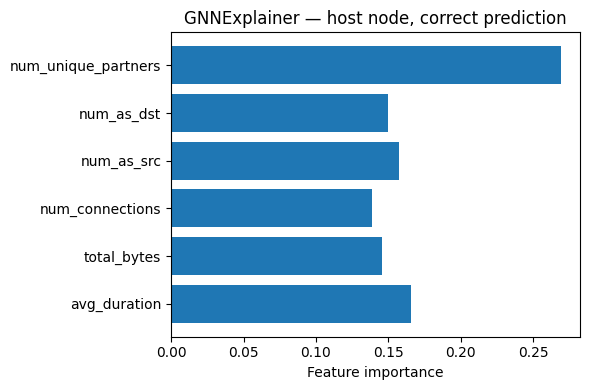

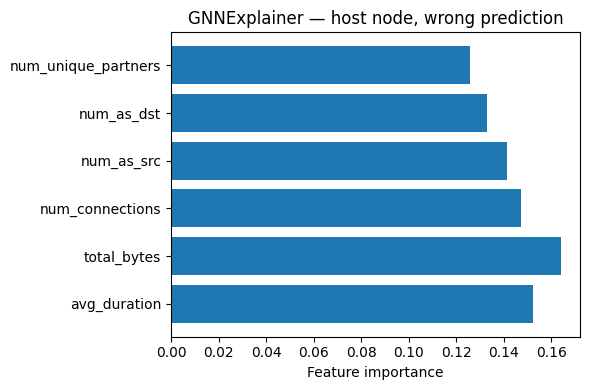

In [9]:
gat_state = torch.load(os.path.join(CFG['gnn_dir'], 'gat_temporal_model.pt'), map_location=device)
model = GAT(in_dim=test_data.x.shape[1], edge_dim=test_data.edge_attr.shape[1],
            hidden_dim=CFG['hidden_dim'], out_dim=2, heads=CFG['heads'], dropout=CFG['dropout']).to(device)
model.load_state_dict(gat_state)
model.eval()

gnn_preds = load_pkl(CFG['gnn_dir'], 'gat_temporal_test_predictions')
correct_host_idx = np.where(gnn_preds['y_pred'] == gnn_preds['y_true'])[0][0]
wrong_host_idx = np.where(gnn_preds['y_pred'] != gnn_preds['y_true'])[0][0]

explainer = Explainer(
    model=model, algorithm=GNNExplainer(epochs=200),
    explanation_type='model', node_mask_type='attributes', edge_mask_type='object',
    model_config=dict(mode='multiclass_classification', task_level='node', return_type='raw'),
)

data = test_data.to(device)
for node_idx, label in [(correct_host_idx, 'correct'), (wrong_host_idx, 'wrong')]:
    explanation = explainer(data.x, data.edge_index, edge_attr=data.edge_attr, index=node_idx)
    feat_importance = explanation.node_mask[node_idx].cpu().numpy()
    plt.figure(figsize=(6, 4))
    # FIX: use actual feature names from CFG instead of fallback
    plt.barh(CFG['node_feature_cols'], feat_importance)
    plt.title(f"GNNExplainer — host node, {label} prediction")
    plt.xlabel("Feature importance")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['out_dir'], f'gnnexplainer_{label}.png'), dpi=150)
    plt.show()